In [1]:
import sys

print("Python version:")
print(sys.version)

print("\nPython executable:")
print(sys.executable)

Python version:
3.13.15 (tags/v3.13.15:4061bc4, Aug  5 2026, 13:05:39) [MSC v.1944 64 bit (AMD64)]

Python executable:
C:\Users\nikhi\Documents\Semiconductor-Wafer-Defect-Detection\tf_venv\Scripts\python.exe


In [2]:
from pathlib import Path

DATA_DIR = Path("../data/WM811k_Dataset")

print("Dataset exists:", DATA_DIR.exists())
print("Dataset path:", DATA_DIR.resolve())

Dataset exists: True
Dataset path: C:\Users\nikhi\Documents\Semiconductor-Wafer-Defect-Detection\data\WM811k_Dataset


In [3]:
classes = sorted([
    folder.name
    for folder in DATA_DIR.iterdir()
    if folder.is_dir()
])

print("Number of classes:", len(classes))
print("\nClasses:")
for i, cls in enumerate(classes):
    print(i, "->", cls)

Number of classes: 9

Classes:
0 -> Center
1 -> Donut
2 -> Edge Local
3 -> Edge Ring
4 -> Local
5 -> Scratch
6 -> near full
7 -> none
8 -> random


In [4]:
image_extensions = {".jpg", ".jpeg", ".png"}

class_counts = {}

for cls in classes:
    class_dir = DATA_DIR / cls
    count = sum(
        1 for file in class_dir.iterdir()
        if file.suffix.lower() in image_extensions
    )
    class_counts[cls] = count

class_counts

{'Center': 100,
 'Donut': 102,
 'Edge Local': 103,
 'Edge Ring': 102,
 'Local': 100,
 'Scratch': 100,
 'near full': 95,
 'none': 100,
 'random': 100}

In [5]:
import pandas as pd

class_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Images"]
)

class_df

,Class,Images
0,Center,100
1,Donut,102
2,Edge Local,103
3,Edge Ring,102
4,Local,100
5,Scratch,100
6,near full,95
7,none,100
8,random,100


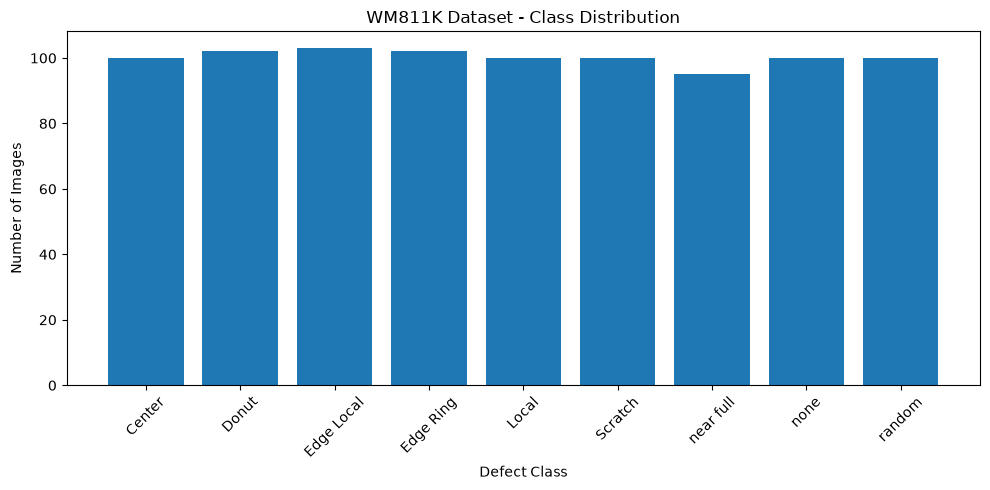

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(class_df["Class"], class_df["Images"])

plt.xlabel("Defect Class")
plt.ylabel("Number of Images")
plt.title("WM811K Dataset - Class Distribution")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

sample_images = []

for cls in classes:
    class_dir = DATA_DIR / cls
    
    images = [
        file for file in class_dir.iterdir()
        if file.suffix.lower() in image_extensions
    ]
    
    if images:
        sample_images.append((cls, images[0]))

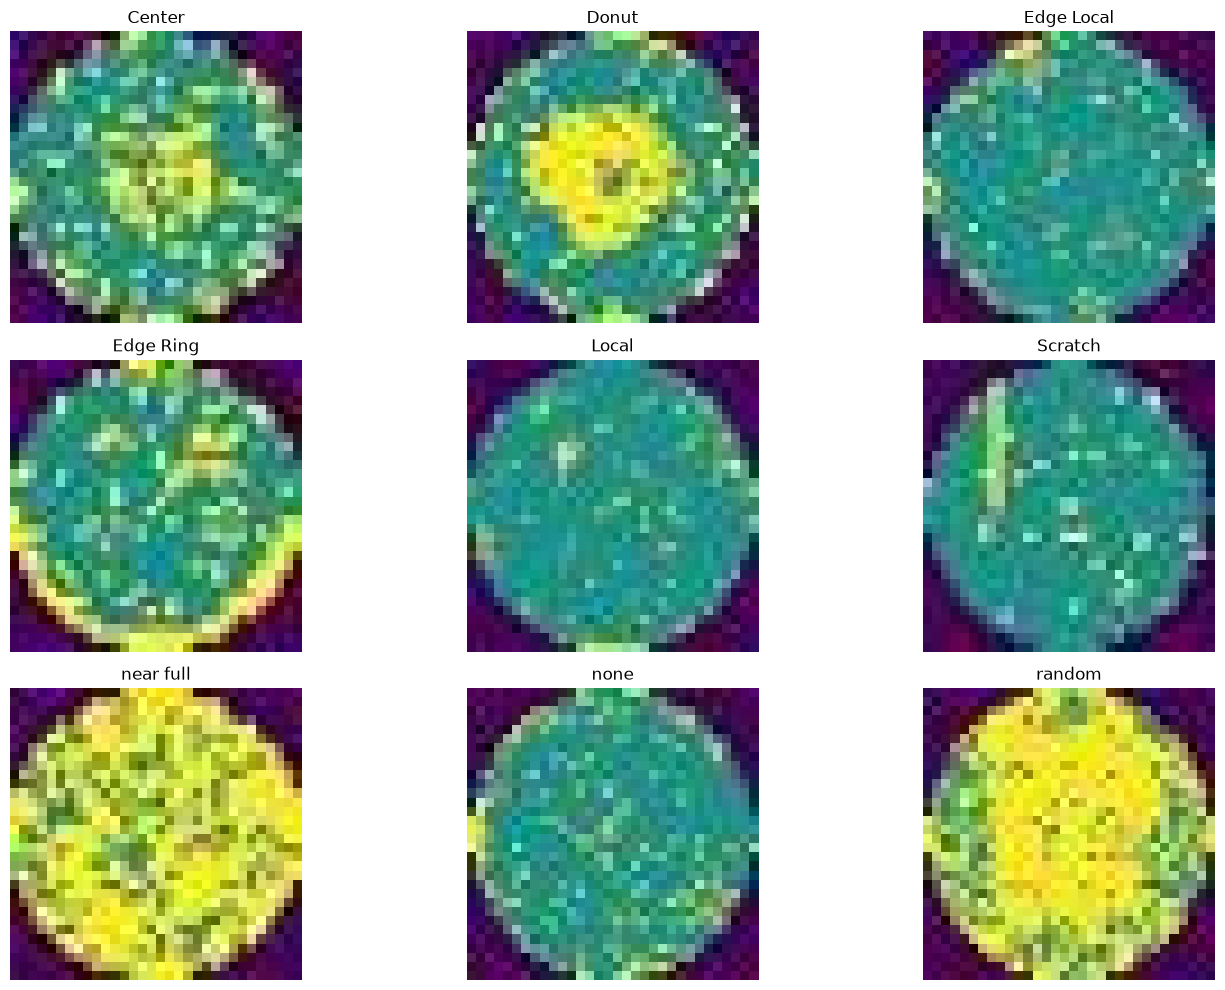

In [8]:
plt.figure(figsize=(15, 10))

for i, (cls, image_path) in enumerate(sample_images):
    image = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()